
# Machine learning Fundamentals Using titanic and iris datasets
Analystlab Africa Machine learning internship

This notebook is for the week 3 of the analystlab africa machine learning internship. in this notebook i will be 

### Goals 
To understand the basic concepts, workflow, and evaluation process involved in Machine Learning.

**Topics to Study**

- Supervised vs Unsupervised Learning

- Understand the difference between supervised and unsupervised learning.

- Learn examples of algorithms under each category.

- Explain real-world use cases for both methods.

**Train/Test Split**

- Learn why datasets are divided into training and testing data.
- Perform a train-test split on your dataset.
- Explain the importance of testing a model before deployment.

**Overfitting vs Underfitting**

- Understand what overfitting and underfitting mean in Machine Learning.
- Explain how they affect model performance.
- Mention possible ways to reduce them.

**Model Evaluation Basics**

- Learn basic evaluation methods used in Machine Learning.
- Understand concepts such as accuracy, confusion matrix, precision, and recall.
- Briefly explain how to determine whether a model performs well or poorly.



Dear Intern,

Welcome to Week 3 of the AnalystLab Africa Machine Learning Internship Program.

This week, you will be introduced to the fundamentals of Machine Learning (ML) and how machine learning models are built and evaluated using data.

Week 3 Topic: Machine Learning Fundamentals

Objective
To understand the basic concepts, workflow, and evaluation process involved in Machine Learning.

Topics to Study

- Supervised vs Unsupervised Learning

- Understand the difference between supervised and unsupervised learning.
- Learn examples of algorithms under each category.
- Explain real-world use cases for both methods.

Train/Test Split

- Learn why datasets are divided into training and testing data.
- Perform a train-test split on your dataset.
- Explain the importance of testing a model before deployment.

Overfitting vs Underfitting

- Understand what overfitting and underfitting mean in Machine Learning.
- Explain how they affect model performance.
- Mention possible ways to reduce them.

Model Evaluation Basics

- Learn basic evaluation methods used in Machine Learning.
- Understand concepts such as accuracy, confusion matrix, precision, and recall.
- Briefly explain how to determine whether a model performs well or poorly.


## Phase 1: Importing needed libraries and the dataset 

In [56]:
#importing the libraries 
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
# importing the datasets 
titanic_path = "/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv"
iris_path = "/kaggle/input/datasets/organizations/uciml/iris/Iris.csv"

titanic_df = pd.read_csv(titanic_path)
iris_df = pd.read_csv(iris_path)


In [58]:
titanic_df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [59]:
iris_df.head(1)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa


In [60]:
# using the function created in week 1 and 2 to clean the datasets 
#------------titanic dataframe cleaning function----------------------------------------------
# creating a function to clean and preprocess the data 
drop_column_list = ["PassengerId", "Name", "Sex", "Ticket", "Cabin"]
encode_colum_list = ["Embarked","title"]
def find_mean(df, column):
    """
    Finds the mean of the continous colum (int,float)
    """
    return df[column].mean()

def find_mode(df,column):
    """
    Finds the mode of the categorical column (object, str)
    """
    return df[column].mode()
    
    
def clean_titanic_df(df, drop_column_list: list ,encode_colum_list: list):
    """
    Cleans the dataframe that is imputed into it 
    Arguments:
    
    """
    # Feature Engineering side 
    # change the Sex column to only is female or not (0,1)
    print("Feature Engineering the Sex column")
    df["is_female"] = (df["Sex"] == "female").astype(int)
    print("Extracting titles from the  Name column")
    # extract the titles on the names of passengers 
    df['title'] = [ln.split()[1] for ln in df["Name"].values]
    df['title'] = [title if title in ['Mr.', 'Miss.', 'Mrs.', 'Master.', 'Dr.', 'Rev.','Baron.','Master.','Mlle.'] else 'Unknown' 
                   for title in df['title'].values ]

    # Preprocessing the data 
    # fill the missing data in the Age column
    print("filling the null values in Age column")
    mean_age = find_mean(df, "Age")
    df["Age"] = df["Age"].fillna(mean_age)
    # fill the missing data in the Embarked column
    print("filling the null values in Embarked column")
    mode_embarked = find_mode(df, "Embarked")
    df["Embarked"] = df["Embarked"].fillna(mode_embarked)
    # standardize the fare column
    # sdc = StandardScaler() # did not want to standardize the Fare column
    # df["Fare"] = sdc.fit_transform(df["Fare"])

    # droping the columns that are not in use 
    print("dropping the unwanted columns")
    df_droped = df.drop(columns = drop_column_list)
    #Encoding the categorical columns 
    print("Encoding the categorical columns")
    df_dummies = pd.get_dummies(df_droped, columns = encode_colum_list, drop_first = True,dtype=int)

    return df_dummies

#---------------------------------------iris cleaning function---------------------------------------

def clean_iris_df(df):
    df = df.copy()

    species_map = {
        "Iris-setosa": 0,
        "Iris-versicolor": 1,
        "Iris-virginica": 2
    }

    df["Species"] = df["Species"].map(species_map)

    return df

In [61]:
# using the function to clean the data
# calling the clean titanic dataset  function 
titanic = clean_titanic_df(titanic_df,drop_column_list,encode_colum_list)

# calling the clean iris dataset function 
iris = clean_iris_df(iris_df)

Feature Engineering the Sex column
Extracting titles from the  Name column
filling the null values in Age column
filling the null values in Embarked column
dropping the unwanted columns
Encoding the categorical columns


## Phase 2: The Study 

### 2.0 Supervised vs Unsupervised learning with 
supervised learning is a machine learning technique where we train a model on a set of labelled data to identify the underlying patterns and relationship.

for example look at this classroom scenerio of  `classwork` and `assignment` in classwork we have the question and answer so we can train ourselves on the classwork question and answer but in the assignment we test ourselves then our teachers (ml Engineer in this case ) evaluate our score.
- this use methods like regression and classification

 While 

Unsupervised learning is when we use machine learning algorithm to analyze and cluster unlabelled data 

- this uses methods like clustering,dimensionality reduction.

### DIfferences betweenn Supervised and unsupervised learning 
1. the data is different Supervised learning uses labelled data while UnSupervised learning uses unlabelled data
2. Supervised learning has Ground truth data While UnSupervised learning doesnt have ground truth data.

### Example Algorithms for Supervised learning.
1. Linear Regression Algorithms
2. randomforest Algorithm
3. naive_bayes Algorithm
4. gradent boosting Algorithm
5. nearest neighbor algorithn
### Example models for UnSupervised learning models
1. k means clustering algorithm

### Examples of real world scenario 
- Supervised learing
The classic fraud detection problem uses a supervised learnig approach where you have a bunch of data labelled as fraud or not-fraud
- UnSupervised learning
an example of this is the movie recomendation  systems that we use nowadays it clusters users to thier most liked categories.


### both of our data are labelled data so we classify our model training as Supervised learning 
- classification for the titanic data in that we are predicting between 2 classes (survived or did not survive)
- also classification for the iris data in that we are predicting between 2 or more classes (class 1, class 2, class 3)
- a regression can be for when we are predicting the price of houses based on thier characteristics (boston house dataset )

In [62]:
# checking the classes in the titanic dataset 
print(titanic_df["Survived"].value_counts())

print("\n")
#also checking the classes in the iris dataset 
print(iris_df["Species"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### 2.1 Train/Test Split
>NOTE: for references puposes i will only be using the titanic dataset



**why datasets are divided into training and testing data**

when training our models on a dataset we need to also test it and see if the model generalises (can predict) on unseen data. therefore getting the model ready for real world scenaros.

- To  perform a split we first have to determine which column is the target column (what we are predicting 'y' ) and then seperate it from the data.
- then we input it into the train_test_split data (make sure to input the percentage of test data to keep)which then splits it into training data and testing data we then use the training data to train the model and the testing data to evaluate the model.

**Explain the importance of testing a model before deployment**

when training a model we are training it to be able to generalise and be versertile not be rigid so testing a model before deployment is paramount it is a step that must not be taken lightly in that if you have tested your model and know its shortcomings you can build on it and then deploy a more polished model instead of a model that wont be able to generalize at the deployment stage.

In [63]:
# using train_test_split from the scikit-learn library to split the titanic data 
# separating the target column from the rest of the data 
y = titanic["Survived"]
X = titanic.drop("Survived", axis = 1)

# importing the library here for inspection sake 
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.3 ,random_state = 43)

print(f"The shape of the training data is {X_train.shape},{y_train.shape} \n While the shape of the testing data is {X_test.shape},{y_test.shape}")

The shape of the training data is (623, 15),(623,) 
 While the shape of the testing data is (268, 15),(268,)


### 2.2 Overfitting vs Underfitting

**Overfitting and Underfitting**

>NOTE:in ml when we train our models we say we are fitting it to the data so i will be using the term fitting to mean trainig the model 

when fitting the model if the model cannot generalise to outside data we say that the model is Overfitting or underfitting
- Overfitting is then the model is too complex so it is very good at predicting the training data only but cannot predict on new data *the model perfroms very well on training data but performs poorly on testing data.*
- underfitting is when the model is too simple and doesnt capture relationships in the data maybe due to a small dataset *the model performs poorly on both training and testing data.*
 
the sweet spot is what we are looking for when fitting the model sweet spot in that the model captures the relationships but is also able to generalise and predict on outside data apart from the training data.
this then introduces the bias-variance tradeoff

- bias is  like assuming all birds can only be small and fly, so the model fails to recognize big birds like ostriches or penguins that can't fly and get biased with predictions.
- Variance is when a model learns too much from a data including the noise (data that has no relationship)

let us use this code to show the relationship between overfitting and underfitting 

Training models and plotting boundaries...


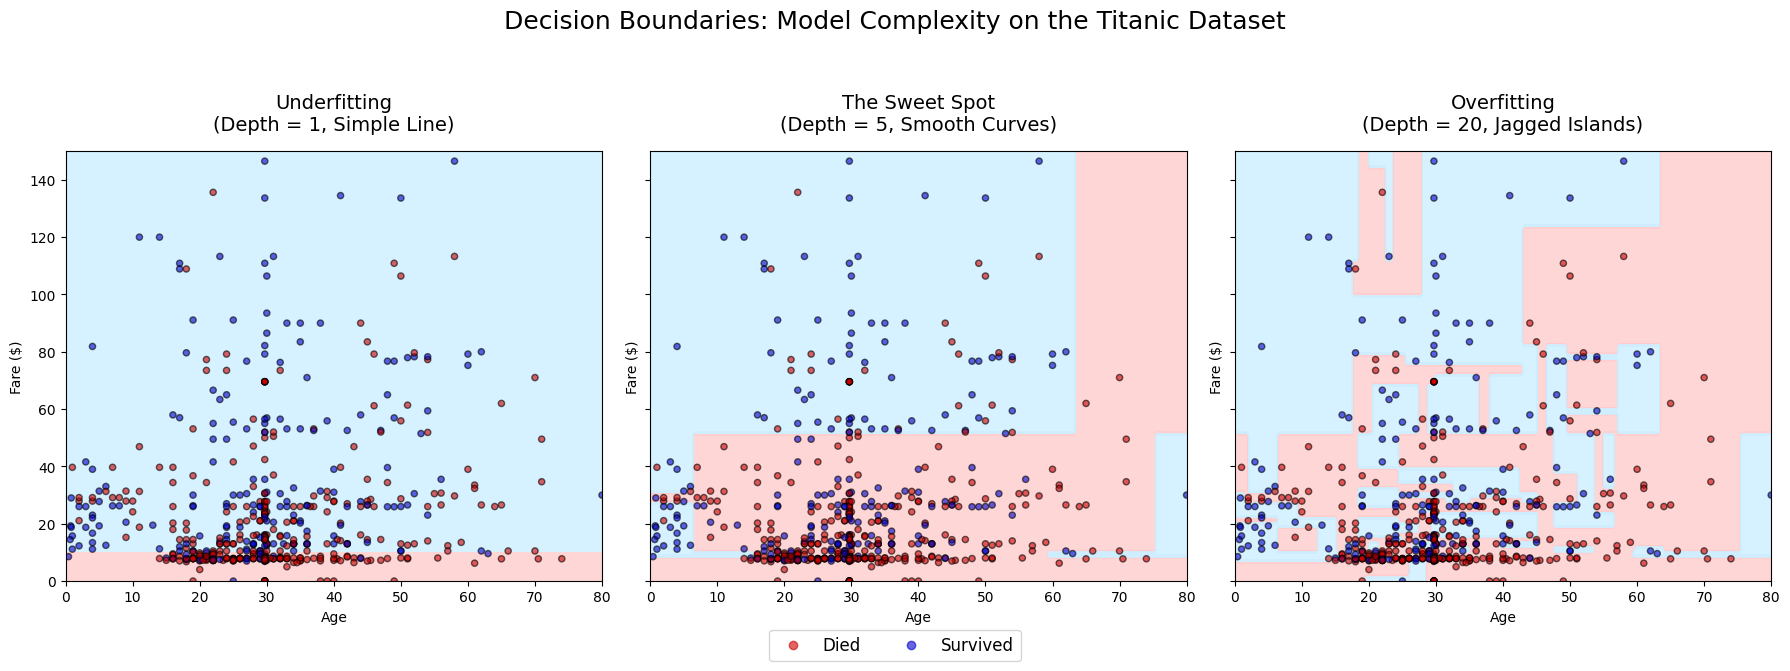

In [64]:
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from matplotlib.colors import ListedColormap



# create a dataframe that contains just two columns
X = pd.DataFrame(data = {'Age':X_train['Age'], 'Fare': X_train['Fare']} )

# get the target data 
y = y_train

# 3. Define the three levels of complexity
models = {
    "Underfitting\n(Depth = 1, Simple Line)": 1,
    "The Sweet Spot\n(Depth = 5, Smooth Curves)": 5,
    "Overfitting\n(Depth = 20, Jagged Islands)": 20
}

# Set up the matplotlib figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
cmap_background = ListedColormap(['#ffcccc', '#cceeff']) # Light red/blue for boundaries
cmap_points = ListedColormap(['#cc0000', '#0000cc'])     # Dark red/blue for data points

# We will zoom in on the axes to ignore massive outliers (like the $512 ticket)
# so the decision boundaries are easier to see.
AGE_MAX = 80
FARE_MAX = 150

print("Training models and plotting boundaries...")
for ax, (title, depth) in zip(axes, models.items()):
    
    # Create and train the model pipeline
    pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    pipeline.fit(X, y)
    
    # Paint the decision boundary background
    display = DecisionBoundaryDisplay.from_estimator(
        pipeline,
        X,
        cmap=cmap_background,
        response_method="predict",
        ax=ax,
        xlabel="Age",
        ylabel="Fare ($)",
        alpha=0.8,
        grid_resolution=300 # Higher resolution for smoother/sharper boundaries
    )
    
    # Scatter the actual passenger data points on top
    scatter = ax.scatter(
        X_train['Age'], X_train['Fare'], 
        c=y, cmap=cmap_points, 
        edgecolor='k', s=20, alpha=0.6
    )
    
    # Formatting the subplot
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlim(0, AGE_MAX)
    ax.set_ylim(0, FARE_MAX)

# Add a universal legend
handles, labels = scatter.legend_elements()
fig.legend(handles, ["Died", "Survived"], loc='lower center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Decision Boundaries: Model Complexity on the Titanic Dataset", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

**Mention possible ways to reduce them.**

For Underfiting 

- you use a more complex model
- add new features and perfrom feature engineering
- scale features properly

For Overfitting 
- collect more training data
- reduce model complexity
- clean noisy data (outliers)


### 2.3 Model Evaluation Basics

evaluation methods are cruicial in machine learning to evaluate how well your model is generalising.
in supervised learning the evaluation used are root mean squared error, mean squared error f1, accuracy , confusion matrix,  precision and recall

for classification:
-  Accuracy measures the overall percentage of correct predictions, it can be deeply misleading with imbalanced data. To truly determine if a model performs well, we use a Confusion Matrix, which breaks predictions into True Positives, False Positives, True Negatives, and False Negatives. From this, we derive Precision (out of all predicted positives, how many were correct?) and Recall (out of all actual positives, how many did we successfully find?). A model performs "well" when it balances these specific metrics according to the real-world problem you are trying to solve.

--- Evaluation Metrics (Cleaned Data) ---
Accuracy:  0.8209
Precision: 0.8000
Recall:    0.7568


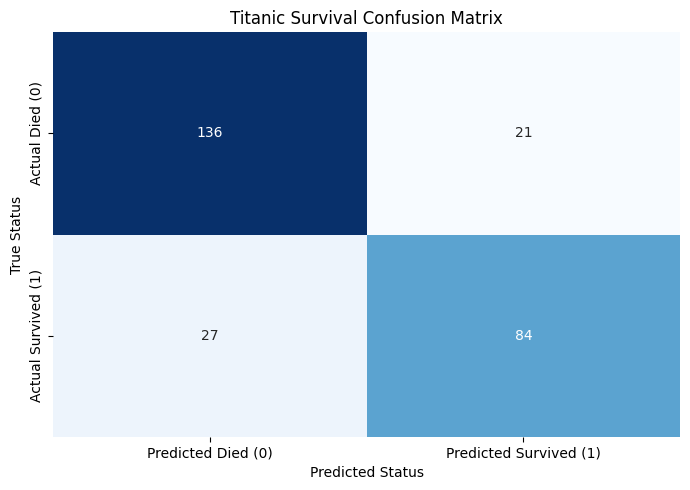

In [65]:
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    precision_score, 
    recall_score
)

# 1. Separate Features (X) and Target (y)
# We drop 'Survived' to create our feature set, and keep only 'Survived' for our target
X = titanic.drop('Survived', axis=1)
y = titanic['Survived']

# 2. Split the data (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize and Train the Model
# We set max_iter=1000 to ensure the math converges properly with all your new title columns
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# 4. Generate Predictions on the unseen test data
y_pred = model.predict(X_test)

# 5. Calculate Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("--- Evaluation Metrics (Cleaned Data) ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

# 6. Visualize the Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Died (0)', 'Predicted Survived (1)'],
            yticklabels=['Actual Died (0)', 'Actual Survived (1)'])
plt.title('Titanic Survival Confusion Matrix')
plt.ylabel('True Status')
plt.xlabel('Predicted Status')
plt.tight_layout()
plt.show()